In [1]:
# ── 0. Install & imports ──────────────────────────────────────────────────────

!pip install -q earth2studio[stormcast]

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import earth2studio.run as run

from datetime import datetime
from scipy.interpolate import RegularGridInterpolator
from earth2studio.models.px import StormCast
from earth2studio.data import GFS_FX
from earth2studio.io import ZarrBackend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.9/821.9 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 M

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1. load model and constants to access variable names and HRRR coordinate system
package = StormCast.load_default_package()
model = StormCast.load_model(package, conditioning_data_source=GFS_FX())

coords = model.input_coords()

VARIABLES = list(coords["variable"])
HRRR_Y = np.asarray(coords["hrrr_y"])
HRRR_X = np.asarray(coords["hrrr_x"])

NY = len(HRRR_Y)
NX = len(HRRR_X)

print("NY, NX:", NY, NX)
print("hrrr_y range:", HRRR_Y.min(), HRRR_Y.max())
print("hrrr_x range:", HRRR_X.min(), HRRR_X.max())

# VARIABLES = [
#     'mslp', 't2m',  'u10m', 'v10m', 'refc',
#     'p1hl', 'p2hl', 'p3hl', 'p4hl', 'p5hl', 'p6hl', 'p7hl', 'p8hl', 'p9hl', 'p10hl', 'p11hl', 'p13hl', 'p15hl', 'p20hl',
#     'q1hl', 'q2hl', 'q3hl', 'q4hl', 'q5hl', 'q6hl', 'q7hl', 'q8hl', 'q9hl', 'q10hl', 'q11hl', 'q13hl', 'q15hl', 'q20hl', 'q25hl', 'q30hl',
#     't1hl', 't2hl', 't3hl', 't4hl', 't5hl', 't6hl', 't7hl', 't8hl', 't9hl', 't10hl', 't11hl', 't13hl', 't15hl', 't20hl', 't25hl', 't30hl',
#     'u1hl', 'u2hl', 'u3hl', 'u4hl', 'u5hl', 'u6hl', 'u7hl', 'u8hl', 'u9hl', 'u10hl', 'u11hl', 'u13hl', 'u15hl', 'u20hl', 'u25hl', 'u30hl',
#     'v1hl', 'v2hl', 'v3hl', 'v4hl', 'v5hl', 'v6hl', 'v7hl', 'v8hl', 'v9hl', 'v10hl', 'v11hl', 'v13hl', 'v15hl', 'v20hl', 'v25hl', 'v30hl',
#     'Z1hl', 'Z2hl', 'Z3hl', 'Z4hl', 'Z5hl', 'Z6hl', 'Z7hl', 'Z8hl', 'Z9hl', 'Z10hl', 'Z11hl', 'Z13hl', 'Z15hl', 'Z20hl', 'Z25hl', 'Z30hl',
# ]

NY, NX: 512 640
hrrr_y range: -768306.1525566636 764693.8474433364
hrrr_x range: -960520.1425219304 956479.8574780696


In [4]:
# 2. MyLocalData ────────────────────────────────────────────────────────────
class MyLocalData:
    """
    Wraps a local numpy array into the xarray interface expected by earth2studio.

    Args:
        data:      numpy array of shape (nt, ny, nx, nc)
        variables: list of nc variable name strings matching StormCast's expected inputs
        lats:      1D array of length ny — y-coordinate values (hrrr_y)
        lons:      1D array of length nx — x-coordinate values (hrrr_x)
        times:     list of nt datetimes, one per time slice in data
    """

    def __init__(self, data: np.ndarray, variables: list[str],
                 hrrr_y: np.ndarray, hrrr_x: np.ndarray, times: list[datetime]):

        nt, ny, nx, nc = data.shape
        assert len(times) == nt,      f"Expected {nt} timestamps, got {len(times)}"
        assert len(variables) == nc,  f"Expected {nc} variable names, got {len(variables)}"
        assert len(hrrr_y) == ny and len(hrrr_x) == nx, "hrrr_y/hrrr_x size mismatch with data grid"

        self.data      = data
        self.variables = variables
        self.hrrr_y = hrrr_y
        self.hrrr_x = hrrr_x
        self.times     = times

    def __call__(self, time: list[datetime], variable: list[str] | str) -> xr.DataArray:
        if isinstance(variable, str):
            variable = [variable]

        # request the first timestamp only to return a single time slice from the list "time"
        requested_time = time[0]
        if requested_time not in self.times:
            raise ValueError(
                f"Requested time {requested_time} not found. "
                f"Available times: {self.times}")

        # get the index of the requested_time from the self.times
        t_idx = self.times.index(requested_time)

        # build an xarray data structure from the given time and data
        da = xr.DataArray(
            self.data[t_idx][np.newaxis, ...],   # (1, ny, nx, nc)
            dims=["time", "hrrr_y", "hrrr_x", "variable"],
            coords={"time":     [time[0]],
                    "hrrr_y":   self.hrrr_y,
                    "hrrr_x":   self.hrrr_x,
                    "variable": self.variables})

        return da.sel(variable=variable).transpose("time", "variable", "hrrr_y", "hrrr_x")

In [5]:
# 3. Regridding helper ──────────────────────────────────────────────────────
def regrid(field: np.ndarray, src_lats: np.ndarray, src_lons: np.ndarray,
           target_lats: np.ndarray, target_lons: np.ndarray) -> np.ndarray:
    """
    Bilinearly interpolate a 2D field (nlat, nlon) from a source lat/lon grid
    onto a target lat/lon grid using scipy's RegularGridInterpolator.

    src_lats must be 1D and can be in any order — they are sorted internally.
    Returns a 2D array of shape (len(target_lats), len(target_lons)).
    """
    # RegularGridInterpolator requires ascending coordinates
    if src_lats[0] > src_lats[-1]:
        src_lats = src_lats[::-1]
        field    = field[::-1, :]

    interp_fn = RegularGridInterpolator(
        (src_lats, src_lons), field,
        method="linear", bounds_error=False, fill_value=np.nan,
    )

    grid_lons, grid_lats = np.meshgrid(target_lons, target_lats)
    points = np.stack([grid_lats.ravel(), grid_lons.ravel()], axis=-1)
    return interp_fn(points).reshape(len(target_lats), len(target_lons))

In [7]:
# 4. Build input array ──────────────────────────────────────────────────────

# Target grid — shared by all variables
ds_era5 = xr.open_dataset("/content/drive/MyDrive/ccrs/models/stormCast/directly_transferrable_variables.nc")
print("List of vars in the current ERA5 data is",list(ds_era5.data_vars))

# extract lat/lon
src_lats = ds_era5.latitude.values
src_lons = ds_era5.longitude.values
print("src_lats range:", src_lats.min(), src_lats.max())
print("src_lons range:", src_lons.min(), src_lons.max())
target_lats = np.linspace(src_lats.max(), src_lats.min(), NY)
target_lons = np.linspace(src_lons.min(), src_lons.max(), NX)

# Initialise with zeros (placeholder for variables not in ERA to be mapped to stormCast)
data = np.zeros((1, NY, NX, len(VARIABLES)), dtype=np.float32)

# ERA5 to StormCast variable insertion
ERA5_TO_STORMCAST = {"t2m": "t2m",
                     "u10": "u10m",
                     "v10": "v10m",
                     "msl": "mslp"}

for era5_name, stormcast_name in ERA5_TO_STORMCAST.items():
    raw = ds_era5[era5_name].isel(valid_time=0).values.astype(np.float32)

    regridded = regrid(
        field=raw,
        src_lats=src_lats,
        src_lons=src_lons,
        target_lats=target_lats,
        target_lons=target_lons,
    ).astype(np.float32)

    if np.isnan(regridded).any():
        raise ValueError(f"NaNs found after regridding {era5_name} → {stormcast_name}")

    idx = VARIABLES.index(stormcast_name)
    data[0, :, :, idx] = regridded

    print(
        f"{era5_name:4s} → {stormcast_name:5s} | "
        f"min={regridded.min():.2f}, "
        f"max={regridded.max():.2f}, "
        f"mean={regridded.mean():.2f}"
    )

List of vars in the current ERA5 data is ['u10', 'v10', 't2m', 'msl']
src_lats range: -5.0 15.0
src_lons range: 95.0 115.0
t2m  → t2m   | min=288.05, max=301.83, mean=299.10
u10  → u10m  | min=-8.33, max=8.06, mean=-0.33
v10  → v10m  | min=-6.74, max=5.00, mean=-1.40
msl  → mslp  | min=100767.06, max=101442.03, mean=100965.23


In [8]:
# 5. Wrap and verify ────────────────────────────────────────────────────────
STARTING_TIME = np.datetime64(ds_era5.valid_time.values[0], "ns")

my_data = MyLocalData(
    data=data,
    variables=VARIABLES,
    hrrr_y=HRRR_Y,
    hrrr_x=HRRR_X,
    times=[STARTING_TIME])

sample = my_data([STARTING_TIME], VARIABLES)
print("Starting time: ", STARTING_TIME)
print("Sample dims: ", sample.dims)
print("Sample shape:", sample.shape)

Starting time:  2025-03-25T00:00:00.000000000
Sample dims:  ('time', 'variable', 'hrrr_y', 'hrrr_x')
Sample shape: (1, 99, 512, 640)


In [9]:
# 6. Inference ──────────────────────────────────────────────────────────────
io = ZarrBackend("stormcast_output_era5.zarr", backend_kwargs={"overwrite": True})
io = run.deterministic(time=[STARTING_TIME], nsteps=3, prognostic=model, data=my_data, io=io)

2026-05-31 04:17:52.337 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-05-31 04:17:52.337 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-05-31 04:17:53.890 | SUCCESS  | earth2studio.run:deterministic:109 - Fetched data from MyLocalData
2026-05-31 04:17:54.470 | INFO     | earth2studio.run:deterministic:139 - Inference starting!



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/

2026-05-31 04:17:57.176 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 0-882604
2026-05-31 04:17:57.191 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 338799805-904942
2026-05-31 04:17:57.199 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 211344107-1173952
2026-05-31 04:17:57.207 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 345504734-941534
2026-05-31 04:17:57.215 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 261515963-813586
2026-05-31 04:17:57.223 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib fi



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-31 04:17:57.340 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 399092975-1216410
2026-05-31 04:17:57.908 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 422644660-945935
2026-05-31 04:17:57.917 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 215251168-602774
2026-05-31 04:17:57.924 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 341886577-1238163
2026-05-31 04:17:57.932 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f000 267790775-926949
2026-05-31 04:17:57.939 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GF

...

2026-05-31 04:20:18.303 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 213521455-751366
2026-05-31 04:20:18.316 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 408220186-966074
2026-05-31 04:20:18.324 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 274375328-930807
2026-05-31 04:20:18.337 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 405119390-1215701
2026-05-31 04:20:18.347 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 218920261-595093
2026-05-31 04:20:18.375 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS



Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

Fetching GFS data:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-31 04:20:18.512 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 415592699-840866
2026-05-31 04:20:18.520 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 273449998-925330
2026-05-31 04:20:18.529 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 403233527-859930
2026-05-31 04:20:18.537 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 345477940-847910
2026-05-31 04:20:18.545 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20250325/00/atmos/gfs.t00z.pgrb2.0p25.f002 429605154-965113
2026-05-31 04:20:18.552 | DEBUG    | earth2studio.data.gfs:fetch_array:367 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:01<00:00, 15.27it/s]

Running inference: 100%|██████████| 4/4 [03:37<00:00, 54.50s/it]

2026-05-31 04:21:32.492 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


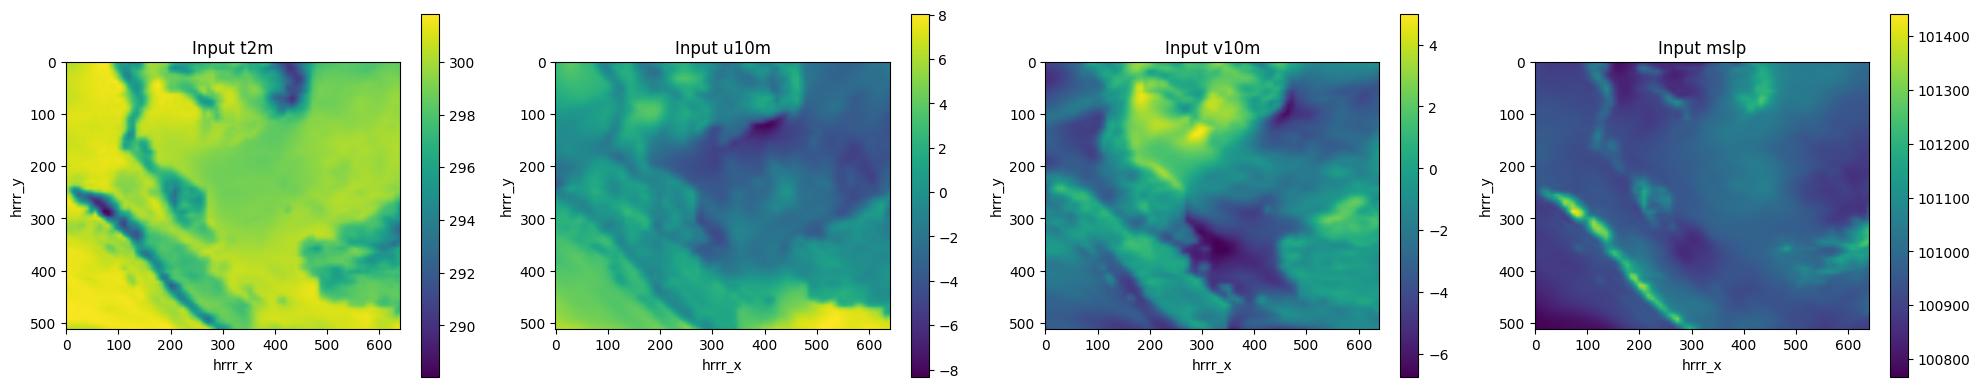

In [10]:
# 7. Plot input ────────────────────────────────────────────────────────────

INPUT_PLOT_VARIABLES = ["t2m", "u10m", "v10m", "mslp"]

fig, axes = plt.subplots(1, len(INPUT_PLOT_VARIABLES), figsize=(5 * len(INPUT_PLOT_VARIABLES), 4))

for ax, var_name in zip(axes, INPUT_PLOT_VARIABLES):
    idx = VARIABLES.index(var_name)
    field = data[0, :, :, idx]

    im = ax.imshow(field, origin="upper")
    ax.set_title(f"Input {var_name}")
    ax.set_xlabel("hrrr_x")
    ax.set_ylabel("hrrr_y")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [11]:
# 8. Plot output ────────────────────────────────────────────────────────────

ds_out = xr.open_zarr("stormcast_output_era5.zarr")

PLOT_VARIABLES = ["t2m", "u10m", "v10m", "mslp"]

n_leads = ds_out.sizes["lead_time"]
n_vars = len(PLOT_VARIABLES)

fig, axes = plt.subplots(
    n_vars,
    n_leads,
    figsize=(5 * n_leads, 4 * n_vars),
    squeeze=False,
)

for row, var_name in enumerate(PLOT_VARIABLES):
    for col in range(n_leads):
        field = ds_out[var_name].isel(time=0, lead_time=col).values

        im = axes[row, col].imshow(field, origin="upper")
        axes[row, col].set_title(f"{var_name} — lead time {col}h")
        axes[row, col].set_xlabel("hrrr_x")
        axes[row, col].set_ylabel("hrrr_y")

        cbar = plt.colorbar(im, ax=axes[row, col])

        if var_name == "t2m":
            cbar.set_label("K")
        elif var_name in ["u10m", "v10m"]:
            cbar.set_label("m/s")
        elif var_name == "mslp":
            cbar.set_label("Pa")
        else:
            cbar.set_label(var_name)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.